In [13]:
# import Pkg
# Pkg.add("OrdinaryDiffEq")

In [14]:
# import Pkg
# Pkg.add("SciMLSensitivity")
# Pkg.add("ADTypes")
# Pkg.add("Zygote")
# Pkg.add("Enzyme")
# Enzyme.API.runtimeActivity(true)
# Pkg.add("Optimization")
# Pkg.add("OptimizationOptimisers")
# Pkg.add("OptimizationOptimJL")
# Pkg.add("LineSearches")
# Pkg.add("Lux")
# Pkg.add("Functors")
import Pkg
Pkg.add("OrdinaryDiffEqSDIRK")
Pkg.add("OrdinaryDiffEqLowOrderRK")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [1]:
using ComponentArrays
using Random
using LinearAlgebra
using SparseArrays
using LinearSolve
using OrdinaryDiffEq
using SciMLSensitivity
using ADTypes
using Zygote
using Enzyme
# Enzyme.API.runtimeActivity!(true)
Enzyme.set_runtime_activity(Enzyme.Reverse)
using Optimization
using OptimizationOptimisers
using OptimizationOptimJL
using LineSearches
using Lux
using Functors
using Plots
using OrdinaryDiffEqSDIRK
using OrdinaryDiffEqLowOrderRK

# 1D Allen-Cahn equation

$$\frac{\partial u}{\partial t} = \nabla^2 u + f(u)$$
where
$$f(u) = u^3 - u$$

**Centered finite difference (FD) stencil implementation:**

*1D Laplacian:*

In [2]:
function lap1d!(du, u, invΔx2)
    du[1] = (u[2] - 2u[1]) * invΔx2
    for i in 2:length(u)-1
        du[i] = (u[i-1] - 2u[i] + u[i+1]) * invΔx2
    end
    du[end] = (u[end-1] - 2u[end]) * invΔx2
end

lap1d! (generic function with 1 method)

*Allen-Cahn RHS:*

In [3]:
function rhs_ac!(du, u, p, t)
    ε2, k, Δx = p.ε2, p.k, p.Δx
    lap1d!(du, u, 1/Δx^2)
    for i in eachindex(du)
        du[i] = ε2*du[i] - k*(u[i]^3 - u[i])
    end
end

rhs_ac! (generic function with 1 method)

Forward solve.

In [4]:
N = 256
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
k = 1.0
p0 = ComponentVector(ε2=ε2, k=k, Δx=Δx)

#u0 = sin.(π*x)
#u0 = 0.5 * (1 .- tanh.((x .- 0.5) / sqrt(2ε2)))
u0 = tanh.((x .- L/2) / sqrt(2ε2))

tspan = (0.0, 2.0)
@show Δt = 0.5 * Δx^2/(2ε2)
t = LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt))

#f = ODEFunction(rhs_ac!)
f = ODEFunction(rhs_ac!; jac_prototype=Tridiagonal(zeros(N-1),zeros(N),zeros(N-1)))

prob = ODEProblem(f, u0, tspan, p0)

alg = Euler()
#alg = TRBDF2()
#alg = TRBDF2(linsolve = KrylovJL_GMRES())
sensalg = GaussAdjoint(autojacvec=EnzymeVJP())
#sensalg = QuadratureAdjoint(autojacvec=EnzymeVJP())

@time sol = solve(prob, alg; dt=Δt, saveat=t)
@time sol = solve(prob, alg; dt=Δt, saveat=t);

Δt = (0.5 * Δx ^ 2) / (2ε2) = 0.0003785068661145513
  0.828591 seconds (3.94 M allocations: 219.212 MiB, 3.87% gc time, 99.12% compilation time)
  0.063496 seconds (15.94 k allocations: 10.912 MiB, 93.46% gc time)


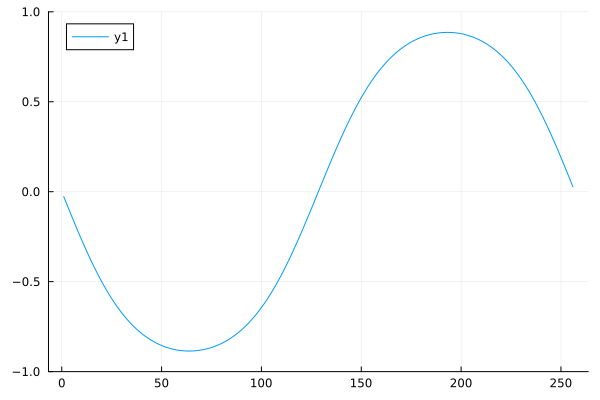

In [5]:
plot(sol.u[end], ylim=(-1,1))

┌ Info: Saved animation to /var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_FCTMleVwHm.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_FCTMleVwHm.gif")
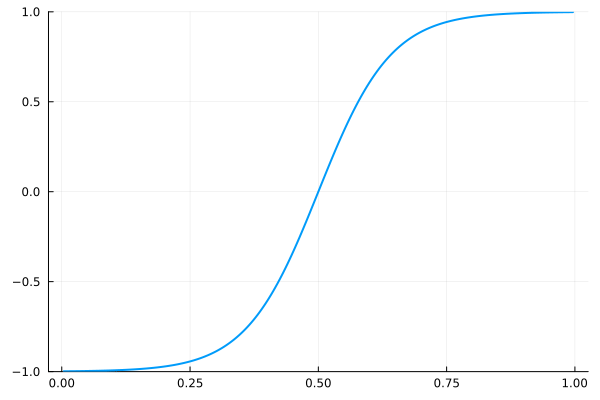

In [6]:
@gif for i in 1:length(sol.t)
    plot(x, sol.u[i], lw=2, ylim=(-1,1), label="")
end every 64

## Pontryagin continuous adjoint

In [7]:
#sensalg = QuadratureAdjoint(autojacvec = EnzymeVJP())
sensalg = GaussAdjoint(autojacvec = EnzymeVJP())

t_obs = [tspan[2]]

model(p) = solve(remake(prob; p=p), alg; dt=Δt, saveat=t_obs, sensealg=sensalg)

model (generic function with 1 method)

In [22]:
function loss_continuous(p)
    sol = model(p)
    0.5 * p.Δx * sum(sol.u[end].^2)
end

loss_continuous (generic function with 1 method)

In [23]:
@time grad_continuous = Zygote.gradient(loss_continuous, p0)[1]
@time grad_continuous = Zygote.gradient(loss_continuous, p0)[1]

  1.224501 seconds (2.43 M allocations: 150.091 MiB, 0.87% gc time, 94.62% compilation time: 100% of which was recompilation)
  0.068495 seconds (252.01 k allocations: 43.586 MiB, 15.22% gc time)


ComponentVector{Float64}(ε2 = -13.887478924255934, k = 0.12186827269125267, Δx = 127.98416020855126)

### Check against finite difference directional derivatives

In [24]:
function directional_fd(loss, p, v; h_rel=1e-6)
    nθ = norm(v)
    h = h_rel * max(1.0, norm(p)) / (nθ == 0 ? 1.0 : nθ)
    (loss(p+h*v) - loss(p-h*v)) / (2h)
end

directional_fd (generic function with 1 method)

In [25]:
println("Continuous model: componentwise finite-difference checks:")
for i in 1:length(p0)
    v = zeros(length(p0))
    v[i] = 1.0
    fd = directional_fd(loss_continuous, p0, v)
    gz = Array(grad_continuous)[i]
    relerr = abs(gz - fd) / max(1.0, abs(fd))
    println("i = $i,  Zygote = $gz,  FD = $fd,  relerr = $relerr")
end

v_rand = randn(length(p0))
fd_rand = directional_fd(loss_continuous, p0, v_rand)
gz_rand = dot(Array(grad_continuous), v_rand)
relerr_rand = abs(gz_rand - fd_rand) / max(1.0, abs(fd_rand))

println()
println("Continuous model, random direction check:")
println("Continuous adjoint·v = $gz_rand")
println("FD      = $fd_rand")
println("relerr  = $relerr_rand")

Continuous model: componentwise finite-difference checks:
i = 1,  Zygote = -13.887478924255934,  FD = -13.89047890545871,  relerr = 0.0002159739216477152
i = 2,  Zygote = 0.12186827269125267,  FD = 0.12189055426067767,  relerr = 2.2281569425006142e-5
i = 3,  Zygote = 127.98416020855126,  FD = 127.99957978764007,  relerr = 0.00012046585710981225

Continuous model, random direction check:
Continuous adjoint·v = -148.59929836174624
FD      = -148.61694998284253
relerr  = 0.0001187725969233619


Error is reasonable.

### Check discrete Euler adjoint via reverse-mode automatic differentation

In [26]:
# function rhs_ac_discrete(u, p, t)
#     du = similar(u)
#     rhs_ac!(du, u, p, t)
#     du
# end

function rhs_ac_discrete(u, p, t)
    ε2, k, Δx = p.ε2, p.k, p.Δx
    invΔx2 = 1/Δx^2
    α = ε2*invΔx2
    N = length(u)
    [ i==1 ? α*(u[2] - 2u[1]) - k*(u[1]^3 - u[1]) :
      i==N ? α*(u[N-1] - 2u[N]) - k*(u[N]^3 - u[N]) :
             α*(u[i+1] - 2u[i] + u[i-1]) - k*(u[i]^3 - u[i])
      for i in 1:N ]
end

function euler_solve(u0, p, t0, dt, nsteps)
    u = u0
    t = t0
    for n in 1:nsteps
        t = t + dt
        u = u + rhs_ac_discrete(u, p, t) * dt
    end
    u
end

euler_solve (generic function with 1 method)

p0 = ComponentVector(ε2 = ε2, k = k, Δx = Δx) = (ε2 = 0.01, k = 1.0, Δx = 0.0038910505836575876)
Δt = (0.5 * Δx ^ 2) / (2ε2) = 0.0003785068661145513
  0.673292 seconds (2.74 M allocations: 160.183 MiB, 47.61% gc time, 99.50% compilation time: <1% of which was recompilation)
  0.033172 seconds (153.68 k allocations: 37.103 MiB, 86.56% compilation time)


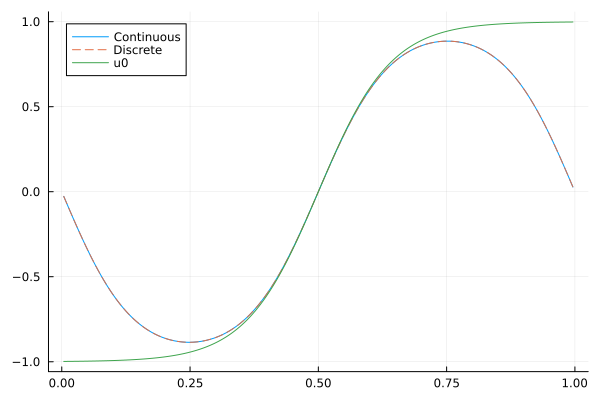

In [27]:
ε2 = 1e-2
k = 1.0
@show p0 = ComponentVector(ε2=ε2, k=k, Δx=Δx)
@show Δt = 0.5 * Δx^2/(2ε2)

f = ODEFunction(rhs_ac!)
prob = ODEProblem(f, u0, tspan, p0)
alg = Euler()
@time sol = solve(prob, alg; dt=Δt, adaptive=false, saveat=t)
cuT = sol.u[end]

nsteps = floor(Int, (tspan[2]-tspan[1])/Δt)
@time duT = euler_solve(u0, p0, tspan[1], Δt, nsteps)

plot(x, cuT, label="Continuous")
plot!(x, duT, label="Discrete", ls=:dash)
plot!(x, u0, label="u0")

In [28]:
function loss_discrete(p)
    uT = euler_solve(u0, p, tspan[1], Δt, nsteps)
    0.5 * Δx * sum(uT.^2)
end

loss_discrete (generic function with 1 method)

AD vs. componentwise and random-direction finite-difference:

In [29]:
function directional_fd_discrete(loss, p, v; h_rel=1e-6)
    nθ = norm(v)
    ratios = [abs(p[i]) < 1 ? 1/abs(v[i]) : abs(p[i])/abs(v[i]) for i in eachindex(v) if v[i] != 0]
    h = h_rel * minimum(ratios) # no component is perturbed by more than h_rel times its own scale
    (loss(p+h*v) - loss(p-h*v)) / (2h)
end

directional_fd_discrete (generic function with 1 method)

In [ ]:
@time grad_discrete = Zygote.gradient(loss_discrete, p0)[1]

println("Discrete model: componentwise finite-difference checks:")
for i in 1:length(p0)
    h_rel = 1e-6
    
    # p₋ = copy(p0); p₋[i] = p0[i] - h_rel
    # p₊ = copy(p0); p₊[i] = p0[i] + h_rel
    # fd = (loss_discrete(p₊) - loss_discrete(p₋)) / (2h_rel)

    v = zeros(length(p0))
    v[i] = 1.0
    @show fd = directional_fd_discrete(loss_discrete, p0, v; h_rel)

    gz = grad_discrete[i]
    relerr = abs(gz - fd) / max(1.0, abs(fd))
    println("i = $i,  Zygote = $gz,  FD = $fd,  relerr = $relerr")
end

v_rand = randn(length(p0))
fd_rand = directional_fd_discrete(loss_discrete, p0, v_rand)
gz_rand = dot(grad_discrete, v_rand)
relerr_rand = abs(gz_rand - fd_rand) / max(1.0, abs(fd_rand))

println()
println("Discrete model, random direction check:")
println("Zygote·v = $gz_rand")
println("FD      = $fd_rand")
println("relerr  = $relerr_rand")


[84481] signal 15: Terminated: 15
in expression starting at /Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/From_Urban/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X34sZmlsZQ==.jl:1
__psynch_cvwait at /usr/lib/system/libsystem_kernel.dylib (unknown line)
unknown function (ip: 0x0) at (unknown file)
obvious_subtype at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XG3Q6T6R70.0/build/default-honeycrisp-XG3Q6T6R70-0/julialang/julia-release-1-dot-12/src/subtype.c:2235
ijl_obvious_subtype at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XG3Q6T6R70.0/build/default-honeycrisp-XG3Q6T6R70-0/julialang/julia-release-1-dot-12/src/subtype.c:2239 [inlined]
ijl_subtype_env at /Users/julia/.julia/scratchspaces/a66863c6-20e8-4ff4-8a62-49f30b1f605e/agent-cache/default-honeycrisp-XG3Q6T6R70.0/build/default-honeycrisp-XG3Q6T6R70-0/julia

This is consistent.

### Continuous adjoint check under timestep refinement

In [ ]:
model(p, dt; adaptive=true) = solve(remake(prob; p=p), alg; dt=dt, adaptive=adaptive, saveat=t_obs, sensealg=sensalg)

function loss_continuous(p, dt; adaptive=true)
    sol = model(p, dt; adaptive=adaptive)
    0.5 * p.Δx * sum(sol.u[end].^2)
end

In [ ]:
#alg = Euler()
#alg = TRBDF2() # this is slow when non-adaptive but faster when adaptive
alg = TRBDF2(linsolve=KrylovJL_GMRES()) # this helps when non-adaptive but is slower when adaptive
sensalg = GaussAdjoint(autojacvec=EnzymeVJP())

ε2 = 1e-2
k = 1.0
p0 = ComponentVector(ε2=ε2, k=k, Δx=Δx)
Δt = 0.5 * Δx^2/(2ε2)

dt1 = Δt
dt2 = Δt/2
dt3 = Δt/4

g1 = Zygote.gradient(p -> loss_continuous(p, dt1; adaptive=false), p0)[1]
g2 = Zygote.gradient(p -> loss_continuous(p, dt2; adaptive=false), p0)[1]
g3 = Zygote.gradient(p -> loss_continuous(p, dt3; adaptive=false), p0)[1]

println("Continuous-adjoint gradient convergence check")
println("dt = $dt1  →  g₁ = ", g1)
println("dt = $dt2  →  g₂ = ", g2)
println("dt = $dt3  →  g₃ = ", g3)

println()

println("‖g₂ - g₁‖ = ", norm(g2-g1))
println("‖g₃ - g₂‖ = ", norm(g3-g2))

println()

rate = norm(g2-g1)/norm(g3-g2)
println("Refinement ratio (Euler ≈ 2, TRBDF2 ≈ 4) = ", rate)

alg = TRBDF2(); # this is a better default for adaptive solves

This checks out.

## Inversion for polynomial free energy

In [ ]:
using ComponentArrays
using Random
using LinearAlgebra
using LinearSolve
using OrdinaryDiffEq
using SciMLSensitivity
using ADTypes
using Zygote
using Enzyme
using Optimization
using OptimizationOptimisers
using OptimizationOptimJL
using LineSearches
using Lux
using Functors
#using Functors.flatten
using Plots

Cubic parameterization of local free energy density

In [ ]:
F(u, θ) = θ[1] + θ[2]*u + θ[3]*u^2 + θ[4]*u^3

In [ ]:
function lap1d!(du, u, invΔx2)
    du[1] = (u[2] - 2u[1]) * invΔx2
    for i in 2:length(u)-1
        du[i] = (u[i-1] - 2u[i] + u[i+1]) * invΔx2
    end
    du[end] = (u[end-1] - 2u[end]) * invΔx2
end

function rhs_ac_f!(du, u, p, t)
    (; ε2, k, Δx, θ) = p
    lap1d!(du, u, 1/Δx^2)
    for i in eachindex(du) # 1:length(u)
        du[i] = ε2*du[i] - F(u[i],θ)
    end
end

function model_f(θ, t=t_obs)
    p = ComponentVector(ε2=ε2, k=k, Δx=Δx, θ=θ)
    solve(remake(prob; p=p), alg; dt=Δt, saveat=t, sensealg=sensalg)
end

In [ ]:
N = 256
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
k = 1.
θref = [0.0, -1.0, 0.0, 1.0]
p0 = ComponentVector(ε2=ε2, k=k, Δx=Δx, θ=θref)

u0 = tanh.((x .- L/2) / sqrt(2ε2))

Δt = 0.5 * Δx^2/(2ε2)
tspan = (0.0, 2.0)
t = LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt))

f = ODEFunction(rhs_ac_f!; jac_prototype=Tridiagonal(zeros(N-1),zeros(N),zeros(N-1)))
prob = ODEProblem(f, u0, tspan, p0)

alg = TRBDF2()
#alg = TRBDF2(linsolve=KrylovJL_GMRES())
sensalg = GaussAdjoint(autojacvec=EnzymeVJP())
#sensalg = QuadratureAdjoint(autojacvec=EnzymeVJP())

N_obs = 10
t_obs = collect(LinRange(tspan[1] + (tspan[2]-tspan[1])/(N_obs-1), tspan[2], N_obs-1))

@time sol_ref = model_f(θref)
@time sol_ref = model_f(θref);

Plot reference solution at observation times (which appear in loss):

In [ ]:
@gif for i in 1:length(sol_ref.t)
    plot(x, sol_ref.u[i], lw=2, ylim=(-1,1), label="")
end

Set up optimization of free energy parameters:

In [ ]:
function loss_ref(θ)
    r = model_f(θ).u - sol_ref.u
    0.5 * Δx * sum(sum(ri.^2) for ri in r)
end

In [ ]:
@show loss_ref(θref)

@time grad = Zygote.gradient(loss_ref, θref)[1]
@time grad = Zygote.gradient(loss_ref, θref)[1];

In [ ]:
θ0 = [0., 0., 0., 0.]

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((θ, p) -> loss_ref(θ), adtype)
optprob = Optimization.OptimizationProblem(optf, θ0)

nprint = 10
cb = function (state, l)
    if state.iter % nprint == 0
        println("iter = $(state.iter),  loss = $l,  θ = ", state.u)
    end
    false
end

Optimize with Adam:

In [ ]:
η = 5e-2
β = (0.9, 0.99)
@time res = Optimization.solve(optprob, OptimizationOptimisers.Adam(η,β); maxiters=500)

@show res.minimum
@show res.u
@show res.u - θref
res.u

Optimize with L-BFGS:

In [ ]:
#using OptimizationOptimJL

In [ ]:
solver = OptimizationOptimJL.LBFGS(
    linesearch = LineSearches.BackTracking(order=2),
    alphaguess = LineSearches.InitialStatic(alpha=1e-1),
)
@time res = Optimization.solve(optprob, solver; maxiters=100) #, callback=cb)

@show res.minimum
@show res.u
@show res.u - θref
res.u

In [ ]:
θopt = res.u

In [ ]:
plot(u -> F(u,θref), xlim=(-1,1), ylim=(-0.5,0.5), lw=2, label="True", title="F(u)")
plot!(u -> F(u,θopt), lw=2, label="Learned", ls=:dash)

In [ ]:
sr = model_f(θref, t)
sf = model_f(θopt, t)

@gif for i in 1:length(sr.t)
    plot(x, sr.u[i], lw=2, ylim=(-1,1), label="True", title="u(x)")
    plot!(x, sf.u[i], lw=2, label="Learned", ls=:dash)    
end every 64

## Inversion for neural network free energy

### Verify NN can reproduce the cubic function

In [ ]:
θtrue = Float32[0.0, -1.0, 0.0, 1.0]

function generate_data(N)
    x = collect(range(-1f0, 1f0, length=N))
    y = similar(x)
    @inbounds for i in eachindex(x)
        y[i] = F(x[i], θtrue)
    end
    reshape(x, 1, :), reshape(y, 1, :)
end

Ntrain = 256
x_train, y_train = generate_data(Ntrain)

rng = Random.default_rng()
Random.seed!(rng, 1)

h = 8
nn = Chain(Dense(1 => h, tanh), Dense(h => h, tanh), Dense(h => 1))
ps, st = Lux.setup(rng, nn)

opt = Optimisers.Adam(0.01f0)
opt_state = Optimisers.setup(opt, ps)

function loss(ps)
    ŷ, _ = Lux.apply(nn, x_train, ps, st)
    r = ŷ - y_train
    sum(r.^2) / size(y_train, 2)
end

nepochs = 1000

for epoch in 1:nepochs
    l, back = Zygote.pullback(loss, ps)
    gs = back(1f0)[1]
    opt_state, ps = Optimisers.update(opt_state, ps, gs)
    if epoch % 100 == 0
        println("epoch = $epoch, loss = $l")
    end
end

x_test = collect(range(-1f0, 1f0, length=100))
x_test_batch = reshape(x_test, 1, :)
y_true = similar(x_test)
@inbounds for i in eachindex(x_test)
    y_true[i] = F(x_test[i], θtrue)
end

function Fnn(u, ps)
    x = reshape(Float32[u], 1, :)
    y, _ = Lux.apply(nn, x, ps, st)
    y[1]
end

plot(u -> F(u,θref), xlim=(-1,1), ylim=(-0.5,0.5), lw=2, label="True")
plot!(u -> Fnn(u,ps), lw=2, label="Neural network", ls=:dash)

In [ ]:
numparams(ps) = sum(length(vec(p.weight))+length(vec(p.bias)) for p in ps)

In [ ]:
numparams(ps)

In [ ]:
opt_st = deepcopy(st)
opt_ps = deepcopy(ps);

### Neural PDE training

In [ ]:
# function lap1d!(du, u, invΔx2)
#     N = length(u)
#     du[1] = 0.0
#     for i in 2:N-1
#         du[i] = invΔx2 * (u[i+1] - 2u[i] + u[i-1])
#     end
#     du[N] = 0.0
#     du
# end

function lap1d!(du, u, invΔx2)
    du[1] = (u[2] - 2u[1]) * invΔx2
    for i in 2:length(u)-1
        du[i] = (u[i-1] - 2u[i] + u[i+1]) * invΔx2
    end
    du[end] = (u[end-1] - 2u[end]) * invΔx2
end

function rhs_ac_F!(du, u, p, t, F)
    (; ε2, k, Δx, θ) = p
    lap1d!(du, u, 1/Δx^2)
    for i in eachindex(du) # 1:length(u)
        du[i] = ε2*du[i] - F(u[i],θ)
    end
end

In [ ]:
### REF

N = 256
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
Δt = 0.5 * Δx^2/(2ε2)
tspan = (0.0, 2.0)
t = LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt))

u0 = tanh.((x .- L/2) / sqrt(2ε2))

function model_f(θ, t=t_obs)
    p = ComponentVector(ε2=ε2, k=k, Δx=Δx, θ=θ)
    solve(remake(prob; p=p), alg; dt=Δt, saveat=t, sensealg=sensalg)
end

f = ODEFunction(rhs_ac_f!; jac_prototype=Tridiagonal(zeros(N-1),zeros(N),zeros(N-1)))
prob = ODEProblem(f, u0, tspan, p0)
@time sol_ref_t = model_f(θref, t);

In [ ]:
function Fnn(u, ps)
    x = reshape([u], 1, :)
    y, _ = Lux.apply(nn, x, ps, st)
    y[1]
end

In [ ]:
function model_FNN(θ, t=t_obs)
    p = ComponentVector(ε2=ε2, k=k, Δx=Δx, θ=re(θ))
    solve(remake(prob; p=p), alg; saveat=t, sensealg=sensalg)
end

Test PDE forward solve with NN trained offline to reproduce known cubic.

In [ ]:
N = 256
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
Δt = 0.5 * Δx^2/(2ε2)
tspan = (0.0, 2.0)
t = LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt))

u0 = tanh.((x .- L/2) / sqrt(2ε2))

ps = opt_ps
st = opt_st
θopt, re = Optimisers.destructure(ps)
p0 = ComponentVector(ε2=ε2, k=k, Δx=Δx, θ=θopt)

f = ODEFunction((du,u,p,t) -> rhs_ac_F!(du, u, p, t, Fnn);
                jac_prototype=Tridiagonal(zeros(N-1),zeros(N),zeros(N-1)))
prob = ODEProblem(f, u0, tspan, p0)

alg = TRBDF2()
sensalg = GaussAdjoint(autojacvec=EnzymeVJP())

p = ComponentVector(ε2=ε2, k=k, Δx=Δx, θ=re(θopt))

@time sol = model_FNN(θopt, t)
@time sol = model_FNN(θopt, t);

In [ ]:
plot(u -> F(u,θref), xlim=(-1,1), ylim=(-0.5,0.5), lw=2, label="True")
plot!(u -> Fnn(u,re(θopt)), lw=2, label="Neural network", ls=:dash)

In [ ]:
@gif for i in 1:length(sol.t)
    plot(x, sol_ref_t.u[i], lw=2, ylim=(-1,1), label="True")
    plot!(x, sol.u[i], lw=2, label="NN", ls=:dash)
end every 64

In [ ]:
function loss_ref_F(θ)
    r = model_FNN(θ).u - sol_ref.u
    0.5 * Δx * sum(sum(ri.^2) for ri in r)
end

Reset NN to learn from scratch.

In [ ]:
nn = Chain(Dense(1=>h,tanh), Dense(h=>h,tanh), Dense(h=>1))
ps, st = Lux.setup(rng, nn)
ps = fmap(x -> Float64.(x), ps)
θ0, re = Optimisers.destructure(ps)

In [ ]:
@time Zygote.gradient(loss_ref_F, θ0)[1]
@time Zygote.gradient(loss_ref_F, θ0)[1];

In [ ]:
adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((θ, p) -> loss_ref_F(θ), adtype)
optprob = Optimization.OptimizationProblem(optf, θ0)
#optprob = Optimization.OptimizationProblem(optf, θ_opt)

η = 5e-2
β = (0.9, 0.99)
N_iter = 400
@time res = Optimization.solve(optprob, OptimizationOptimisers.Adam(η,β); maxiters=N_iter)

res.minimum

In [ ]:
θ_opt = res.u               # optimized flat parameter vector
ps_opt = re(θ_opt)          # rebuild Lux parameter tree

us = range(-1, 1; length=200)
Fvals = [Fnn(u, ps_opt) for u in us]

#plot(us, Fvals, xlabel="u", ylabel="F_nn(u)", lw=2, legend=false)
plot(u -> F(u,θref), xlim=(-1,1), ylim=(-0.7,0.7), lw=2, label="True")
plot!(us, Fvals, lw=2, label="Neural network", ls=:dash)

## Model reduction

In [ ]:
function lap1d!(du, u, invΔx2)
    du[1] = (u[2] - 2u[1]) * invΔx2
    for i in 2:length(u)-1
        du[i] = (u[i-1] - 2u[i] + u[i+1]) * invΔx2
    end
    du[end] = (u[end-1] - 2u[end]) * invΔx2
end

In [ ]:
function rhs_ac!(du, u, p, t)
    ε2, k, Δx = p.ε2, p.k, p.Δx
    lap1d!(du, u, 1/Δx^2)
    for i in eachindex(du)
        du[i] = ε2*du[i] - k*(u[i]^3 - u[i])
    end
end

In [ ]:
function rhs_ac_matrix!(du, u, p, t)
    (A,f) = p
    du .= A*u - f.(u)
end

In [ ]:
f_ac(u) = u^3 - u

In [ ]:
### REF

N = 512
L = 1.0xnx
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
@show Δt = 0.5 * Δx^2/(2ε2)
#Δt = 1/65536
tspan = (0.0, 1.0)
t = collect(LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt)))

A = (ε2 / Δx^2) * spdiagm(-1 => fill(1.0,N-1), 0 => fill(-2.0,N), 1 => fill(1.0,N-1));

u0 = tanh.((x .- L/2) / sqrt(2ε2))

#p0 = ComponentArray(ε2=ε2, k=k, Δx=Δx)
#f = ODEFunction(rhs_ac!)
p0 = (A,f_ac)
f = ODEFunction(rhs_ac_matrix!)
prob = ODEProblem(f, u0, tspan, p0)
alg = TRBDF2()
@time sref = solve(prob, alg; dt=Δt, saveat=t);

In [ ]:
@gif for i in 1:length(sref.t)
    plot(x, sref.u[i], lw=2, label="", ylim=(-1.1,1.1))
end every 256

### Basis construction

POD basis:

In [ ]:
u = hcat(sref.u...)
U,DU,_ = svd(u)
plot(DU/DU[1], yaxis=:log10, xtick=0:5:100, ytick=10.0 .^ (-18:0), lw=2, xlim=(1,100), ylim=(1e-17,1), title="POD basis", label="Eigenvalues (normalized)")

DEIM basis:

In [ ]:
#fu = F.(u, Ref(θref))
fu = -f_ac.(u)

V,DV,_ = svd(fu)
plot(DV/DV[1], yaxis=:log10, xtick=0:5:250, ytick=10.0 .^ (-17:0), lw=2, xlim=(1,60), ylim=(1e-17,1), label="Eigenvalues (normalized)")

In [ ]:
@gif for i = 1:size(fu,2)
    p1 = plot(x, u[:,i], lw=2, ylim=(-1.1,1.1), title="u", label="")
    p2 = plot(x, -fu[:,i], lw=2, ylim=(-0.5,0.5), title="F(u)", label="")
    plot(p1, p2, size=(800,400))
end every 64

### Linear matrix construction

In [ ]:
A = (ε2 / Δx^2) * spdiagm(-1 => fill(1.0,N-1), 0 => fill(-2.0,N), 1 => fill(1.0,N-1))

du = similar(u0)
lap1d!(du, u0, 1/Δx^2)
norm(A*u0 - ε2*du)

In [ ]:
# function matrix_from_action_fill!(lin!, N, invΔx2)
#     A  = spzeros(Float64, N, N)
#     e  = zeros(Float64, N)
#     du = zeros(Float64, N)
#     for j in 1:N
#         fill!(e, 0.0)
#         e[j] = 1.0
#         lin!(du, e, invΔx2)
#         A[:,j] = sparse(du)
#     end
#     A
# end

# L = matrix_from_action(lap1d!, N, 1/Δx^2)
# A = ε2 * L
# norm(A*u0 - ε2*du)

### POD-Galerkin ROM

In [ ]:
function build_rom(A, f, u, fu, r, m)
    U, V = svd(u).U[:,1:r], svd(fu).U[:,1:m]
    p = vcat(argmax(abs.(V[:,1])), zeros(Int,m-1))
    for k = 1:m-1
        p[k+1] = argmax(abs.(V[:,1:k]*(V[p[1:k],1:k]\V[p[1:k],k+1]) - V[:,k+1]))
    end
    (U=U, V=V, Ã=U'*(A*U), f=f, p=p, Up=U[p,:], Vp=V[p,:], B=(V[p,:]'\(V'U))')
end

In [ ]:
rom_rhs!(dũ, ũ, (U,V,Ã,f,p,Up,Vp,B), t) = dũ .= Ã*ũ + B*f.(Up*ũ)

In [ ]:
r = 10
m = 10
@time p_rom = build_rom(A, u -> -f_ac(u), u, fu, r, m);

In [ ]:
@time sref = solve(prob, alg; dt=Δt, saveat=t)
@time sref = solve(prob, alg; dt=Δt, saveat=t)

ode_rom = ODEFunction(rom_rhs!)
prob_rom = ODEProblem(ode_rom, p_rom.U'u0, tspan, p_rom)
alg = TRBDF2()
@time sol_rom = solve(prob_rom, alg; saveat=t)
@time sol_rom = solve(prob_rom, alg; saveat=t)
u_recon = p_rom.U * hcat(sol_rom.u...);

In [ ]:
@gif for i in 1:length(sref.t)
    plot(x, sref.u[i], lw=2, ylim=(-1.1,1.1), label="FOM")
    plot!(x, u_recon[:,i], lw=2, label="ROM", ls=:dash)
end every 64

## ROM inversion

In [ ]:
using ComponentArrays
using Random
using LinearAlgebra
using SparseArrays
using LinearSolve
using OrdinaryDiffEq
using SciMLSensitivity
using ADTypes
using Zygote
using Enzyme
using Optimization
using OptimizationOptimisers
using OptimizationOptimJL
using LineSearches
using Lux
using Functors
using Plots

In [ ]:
N = 512
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)
ε2 = 1e-2
k = 1.
Δt = 0.5 * Δx^2/(2ε2)
tspan = (0.0, 1.0)
t = collect(LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt)));

In [ ]:
f_ac(u) = u^3 - u

function rhs_ac_matrix!(du, u, p, t)
    (A,f) = p
    du .= A*u - f.(u)
end

A = (ε2 / Δx^2) * spdiagm(-1 => fill(1.0,N-1), 0 => fill(-2.0,N), 1 => fill(1.0,N-1));

u0 = tanh.((x .- L/2) / sqrt(2ε2))

p0 = (A,f_ac)
f = ODEFunction(rhs_ac_matrix!)
prob = ODEProblem(f, u0, tspan, p0)
alg = TRBDF2()
@time sref = solve(prob, alg; dt=Δt, saveat=t)

u = hcat(sref.u...)
fu = -f_ac.(u);

In [ ]:
function Fnn_full(u, nn, ps, st)
    x = reshape([u], 1, :)
    y, _ = Lux.apply(nn, x, ps, st)
    y[1]
end

In [ ]:
function build_rom_NN(A, nn, θ, st, u, fu, r, m)
    U, V = svd(u).U[:,1:r], svd(fu).U[:,1:m]
    p = vcat(argmax(abs.(V[:,1])), zeros(Int,m-1))
    for k = 1:m-1
        p[k+1] = argmax(abs.(V[:,1:k]*(V[p[1:k],1:k]\V[p[1:k],k+1]) - V[:,k+1]))
    end
    (U=U, V=V, Ã=U'*(A*U), nn=nn, θ=θ, st=st, p=p, Up=U[p,:], Vp=V[p,:], B=(V[p,:]'\(V'U))')
end

function build_rom_NN(A, θ, u, fu, r, m)
    U, V = svd(u).U[:,1:r], svd(fu).U[:,1:m]
    p = vcat(argmax(abs.(V[:,1])), zeros(Int,m-1))
    for k = 1:m-1
        p[k+1] = argmax(abs.(V[:,1:k]*(V[p[1:k],1:k]\V[p[1:k],k+1]) - V[:,k+1]))
    end
    (U=U, V=V, Ã=U'*(A*U), θ=θ, p=p, Up=U[p,:], Vp=V[p,:], B=(V[p,:]'\(V'U))')
end

function build_rom_NN(A, u, fu, r, m)
    U, V = svd(u).U[:,1:r], svd(fu).U[:,1:m]
    p = vcat(argmax(abs.(V[:,1])), zeros(Int,m-1))
    for k = 1:m-1
        p[k+1] = argmax(abs.(V[:,1:k]*(V[p[1:k],1:k]\V[p[1:k],k+1]) - V[:,k+1]))
    end
    (U=U, V=V, Ã=U'*(A*U), p=p, Up=U[p,:], Vp=V[p,:], B=(V[p,:]'\(V'U))')
end

#rom_rhs_NN!(dũ, ũ, (U,V,Ã,θ,p,Up,Vp,B), t) = dũ .= Ã*ũ + B*Fnn.(Up*ũ, Ref(rer(θ)))

# function rom_rhs_NN!(dũ, ũ, p, t)
#     (; Ã, nn, θ, st, Up, B) = p
#     ps = rer(θ)
#     dũ .= Ã*ũ + B*Fnn_full.(Up*ũ, Ref(nn), Ref(ps), Ref(st))
# end

# function rom_rhs_NN!(dũ, ũ, p, t)
#     (; Ã, θ, Up, B) = p
#     ps = rer(θ)
#     dũ .= Ã*ũ + B*Fnn_full.(Up*ũ, Ref(nnr), Ref(ps), Ref(str))
# end

function rom_rhs_NN!(dũ, ũ, p, t)
    (; Ã, θ, Up, B) = p
    dũ .= Ã*ũ + B*Fnn_full.(Up*ũ, Ref(nnr), Ref(θ), Ref(str))
end

# function rom_rhs_NN!(dũ, ũ, p, t)
#     (; Ã, Up, B, θ) = p
#     z = Up*ũ
#     fz = similar(z)
#     @inbounds for i in eachindex(z)
#         fz[i] = Fnn_full(z[i], nnr, θ, str)
#     end
#     dũ .= Ã*ũ + B*fz
# end

# function rom_rhs_NN!(dũ, ũ, p, t)
#     (; Ã, Up, B, θ) = p
#     z = Up*ũ
#     fz = similar(z)
#     @inbounds for i in eachindex(z)
#         fz[i] = Fnn_full(z[i], nnr, θ, str)
#     end
#     tmp = similar(dũ)
#     mul!(dũ, Ã, ũ)
#     mul!(tmp, B, fz)
#     @inbounds for i in eachindex(dũ)
#         dũ[i] += tmp[i]
#     end
# end

function rom_rhs_NN!(dũ, ũ, p, t)
    (; Ã, θ, Up, B) = p

    z = Up * ũ
    fz = similar(z)
    @inbounds for i in eachindex(z)
        fz[i] = Fnn_full(z[i], nnr, θ, str)
    end

    rhs = Ã * ũ + B * fz
    dũ[:] = rhs
    return nothing
end

function rom_rhs_NN!(dũ, ũ, p, t)
    (; Ã, θ, Up, B) = p

    # dũ = Ã * ũ  (no BLAS)
    @inbounds for i in axes(Ã, 1)
        s = 0.0
        for j in axes(Ã, 2)
            s += Ã[i, j] * ũ[j]
        end
        dũ[i] = s
    end

    # dũ += B * F(Up * ũ)  (no BLAS, no broadcast, no temporary vectors)
    @inbounds for j in axes(Up, 1)
        z = 0.0
        for k in axes(Up, 2)
            z += Up[j, k] * ũ[k]
        end
        fj = Fnn_full(z, nnr, θ, str)
        for i in axes(B, 1)
            dũ[i] += B[i, j] * fj
        end
    end

    return nothing
end

In [ ]:
function Fnn_rom(u, ps)
    x = reshape([u], 1, :)
    y, _ = Lux.apply(nnr, x, ps, str)
    return y[1]
end

function rom_rhs_NN!(dũ, ũ, p, t)
    (; Ã, θ, Up, B) = p
    dũ .= Ã * ũ + B * Fnn_rom.(Up * ũ, Ref(θ))
end

In [ ]:
rng = Random.default_rng()
Random.seed!(rng, 1)

# h = 8
# nnr = Chain(Dense(1=>h,tanh), Dense(h=>h,tanh), Dense(h=>1))
# psr, str = Lux.setup(rng, nnr)
# psr = fmap(x -> Float64.(x), psr)
# θ0r, rer = Optimisers.destructure(psr)

h = 8
nnr = Chain(Dense(1=>h,tanh), Dense(h=>h,tanh), Dense(h=>1))
psr, str = Lux.setup(rng, nnr)
psr = fmap(x -> Float64.(x), psr)
θ0r, rer = Optimisers.destructure(psr);

In [ ]:
r = 10
m = 10
#@time p_rom_NN = build_rom_NN(A, nnr, θ0r, str, u, fu, r, m);
###@time p_rom_NN = build_rom_NN(A, θ0r, u, fu, r, m)
@time pr = build_rom_NN(A, u, fu, r, m);

In [ ]:
# ũ = p_rom_NN.U' * u0

# dũ = similar(ũ)
# rom_rhs_NN!(dũ, ũ, p_rom_NN, t)

In [ ]:
N_obs = 10
t_obs = collect(LinRange(tspan[1] + (tspan[2]-tspan[1])/(N_obs-1), tspan[2], N_obs-1))

p0 = (A,f_ac)
f = ODEFunction(rhs_ac_matrix!)
prob = ODEProblem(f, u0, tspan, p0)
alg = TRBDF2()
@time sref = solve(prob, alg; dt=Δt, saveat=t_obs);

In [ ]:
ode_rom_NN = ODEFunction(rom_rhs_NN!)
prob_rom_NN = ODEProblem(ode_rom_NN, p_rom_NN.U' * u0, tspan, p_rom_NN)

#θ = deepcopy(θ0r)
#pr = deepcopy(p_rom_NN)
#p = (U=pr.U, V=pr.V, Ã=pr.Ã, nn=pr.nn, θ=θ, st=pr.st, p=pr.p, Up=pr.Up, Vp=pr.Vp, B=pr.B)

#p0_rom = (U=pr.U, V=pr.V, Ã=pr.Ã, θ=psr, p=pr.p, Up=pr.Up, Vp=pr.Vp, B=pr.B)
p0_rom = ComponentArray(Ã=p_rom_NN.Ã, Up=p_rom_NN.Up, B=p_rom_NN.B, θ=psr)
alg = TRBDF2()
sensalg = GaussAdjoint(autojacvec=EnzymeVJP())
@time solve(remake(prob_rom_NN; p=p0_rom), alg; saveat=t, sensealg=sensalg);

In [ ]:
# function model_rom(θ, t=t_obs)
#     pr = p_rom_NN
#     #p = (U=pr.U, V=pr.V, Ã=pr.Ã, nn=pr.nn, θ=θ, st=pr.st, p=pr.p, Up=pr.Up, Vp=pr.Vp, B=pr.B)
#     p = ComponentArray(Ã=p_rom_NN.Ã, Up=p_rom_NN.Up, B=p_rom_NN.B, θ=ps)
#     alg = TRBDF2()
#     sensalg = GaussAdjoint(autojacvec=EnzymeVJP())
#     solr = solve(remake(prob_rom_NN; p=p), alg; saveat=t, sensealg=sensalg)
#     u = p.U*hcat(solr.u...)
# end

# function model_rom(θ, t=t_obs)
#     pr = p_rom_NN
#     p = ComponentArray(U=pr.U, V=pr.V, Ã=pr.Ã, θ=θ, p=pr.p, Up=pr.Up, Vp=pr.Vp, B=pr.B)
#     solr = solve(remake(prob_rom_NN; p=p), alg; saveat=t, sensealg=sensalg)
#     p.U*hcat(solr.u...)
# end

function model_rom(θ, t=t_obs)
    ps = rer(θ)
    p = ComponentArray(Ã=p_rom_NN.Ã, Up=p_rom_NN.Up, B=p_rom_NN.B, θ=ps)
    alg = TRBDF2(autodiff=false)
    sensalg = GaussAdjoint(autojacvec=EnzymeVJP())
    solr = solve(remake(prob_rom_NN; p=p), alg; saveat=t, sensealg=sensalg)
    p_rom_NN.U * hcat(solr.u...)
end

In [ ]:
srefv = hcat(sref.u...)

function loss_rom(θ)
    res = model_rom(θ) - srefv
    0.5 * Δx * sum(sum(r.^2) for r in res)
end

In [ ]:
loss_rom(θ0r)

In [ ]:
#Zygote.gradient(θ -> model_rom(θ)[end][1], θ0r)[1]

In [ ]:
mode = Enzyme.set_runtime_activity(Enzyme.Reverse)

In [ ]:
@time Zygote.gradient(loss_rom, θ0r)[1]
@time Zygote.gradient(loss_rom, θ0r)[1];

In [ ]:
adtype = Optimization.AutoZygote()
optf_rom = Optimization.OptimizationFunction((θ, p) -> loss_rom(θ), adtype)
#optprob_rom = Optimization.OptimizationProblem(optf_rom, θ0r)
optprob = Optimization.OptimizationProblem(optf_rom, θ_opt_rom)

η = 5e-2
β = (0.9, 0.99)
N_iter = 1000
@time res_rom = Optimization.solve(optprob_rom, OptimizationOptimisers.Adam(η,β); maxiters=N_iter)

res_rom.minimum

In [ ]:
θ_opt_rom = res_rom.u               # optimized flat parameter vector
ps_opt_rom = rer(θ_opt_rom)          # rebuild Lux parameter tree

us = range(-1, 1; length=200)
###Fvals = [Fnn(u, ps_opt_rom) for u in us]
Fvals = [Fnn_full(u, nnr, ps_opt_rom, str) for u in us]
#plot(us, Fvals, xlabel="u", ylabel="F_nn(u)", lw=2, legend=false)
plot(u -> u^3 - u, xlim=(-1,1), ylim=(-0.7,0.7), lw=2, label="True", title="F(u)")
plot!(us, -Fvals, lw=2, label="NN ROM", ls=:dash)

In [ ]:
srom = model_rom(θ_opt_rom, t);

### REF

N = 512
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
@show Δt = 0.5 * Δx^2/(2ε2)
#Δt = 1/65536
tspan = (0.0, 1.0)
t = collect(LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt)))

A = (ε2 / Δx^2) * spdiagm(-1 => fill(1.0,N-1), 0 => fill(-2.0,N), 1 => fill(1.0,N-1));

u0 = tanh.((x .- L/2) / sqrt(2ε2))

#p0 = ComponentArray(ε2=ε2, k=k, Δx=Δx)
#f = ODEFunction(rhs_ac!)
p0 = (A,f_ac)
f = ODEFunction(rhs_ac_matrix!)
prob = ODEProblem(f, u0, tspan, p0)
alg = TRBDF2()
@time sref = solve(prob, alg; dt=Δt, saveat=t);

In [ ]:
@gif for i in 1:length(sref.t)
    plot(x, sref.u[i], lw=2, label="True", title="u")
    plot!(x, srom[:,i], lw=2, ls=:dash, label="NN ROM")
end every 64